<a href="https://colab.research.google.com/github/CruzJulio05/Investigaci-n-de-operaciones-/blob/main/Actividad_Networkx1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ***<font color="green#">TUTORIAL DE NETWORKX***

Introducción


Objetivo

1$)$ Resolviendo el arból de expansión mínima por redes no dirigidas.

In [ ]:
#Networkx permite crear y analizar grafos.
import networkx as nx

#Matplotlib permite la visualización del grafo
import matplotlib.pyplot as plt

In [ ]:
from IPython.display import Image, display

url = "https://raw.githubusercontent.com/CruzJulio05/Investigaci-n-de-operaciones-/main/actividad_1_a.png"
display(Image(url=url))

El algoritmo de árbol de expansión mínima enlaza los nodos de una red, en forma directa o indirecta, con la mínima longitud de las ramas enlazantes.

Entendamos el procediemto del algoritmo para resolverlo y es el siguiente:

Sea $N={1, 2, ..., n}$ el conjunto de nodos de la red, y se definen como

$C_k$ = Conjunto de nodos que se han conectado en forma permanente en la iteración k.

$\bar{C_k}$ = Conjunto de nodos que todavía se deben conectar en forma permanente.

**Paso 0.** El conjunto $C_0 = \emptyset$ y $\bar{C_0}=N $

**Paso 1.** Comenzar con cualquier nodo en el conjunto $\bar{C_0}$ no conectado (o “inconexo”), e igualar $C_1$={$i$} , con lo que $\bar{C_1}$=N-{$i$} . Igualar $k = 2.$

**Paso general k**. Seleccionar un nodo $j$ en el conjunto no conectado $\bar{C}_{k-1}$ que produzca el arco más corto a un nodo, en el conjunto conectado $C_{k-1}$. Enlazar a $j$ en forma permanente con $C_{k-1}$ y sacarlo de $\bar{C}_{k-1}$ , esto es

<center>$C_k = C_{k-1}+ {j}, \bar{C_k}$=$\bar{C}_{k-1}-{j}$</center>

Si el conjunto $\bar{C_k}$, de nodos no conectados es vacío, detenerse. En cualquier otro caso, igualar $k = k+1$ y repetir el paso.




Resolviendo el ejercicio $1)$ en base con lo anterior, tenemos:

In [ ]:
redes=[
    (1,2,5),(1,3,1),(3,2,2),(2,6,6),(6,2,7),(2,4,7),(2,5,1),
           (3,4,6),(4,3,7),(3,5,7),(4,6,4),(4,7,6),(5,4,3),(5,6,5),
           (5,7,9),(6,7,2)
]

U=nx.Graph() #Crea una red no dirigida, donde la arista (u,v) es igual a (v,u).
for u,v,w in redes:     #Con for recorrer todas las 16 tuplas siendo (origen, destino, valor)
  if U.has_edge(u,v):     #Ya se puede tomar las rutas en ambos sentidos sin que sea dirigida
    U[u][v]["weight"]=min(U[u][v]["weight"],w) #Tomar el minimo valor
  else:
    U.add_edge(u,v,weight=w)

In [ ]:
#Hacemos uso de pos, siendo la posición de cada nodo en (x,y)
pos={1:(0.0,1.0),2:(1.6,2.0), 3:(1.6,0.0), 4:(3.6,1.0),
       6:(5.6,2.0), 5:(5.6,0.0), 7:(7.2,1.0)}

curvas={(2,5):-0.22} #vamos a curvar la linea de 2-5, detras del nodo 4

inicio=4

N=set(U.nodes) #convertimos los nodos en un conjunto, correspondientes a N.

#Inicia las iteraciones C_k y guarda los valores, longitudes y las redes del arbol.
estado={1:{"C":{inicio},"Cb":N-{inicio},"l":0, "arbol":[]}}



In [ ]:
#Definimos la función, la cual, recibe la iteración k y lee le estado k-1
def iteracion(k):
  previo=estado[k-1]
  C,Cb=previo["C"],previo["Cb"]
  candidatos=sorted((U[i][j]["weight"],i,j) #Recorre cada i,j en C, se queda con los que tiene  redes y valores
                    for i in C for j in Cb if U.has_edge(i, j)) #sorted ordena de menos a mayor distancia
  print("redes candidatas (C -> C barras):")
  for w, i, j in candidatos:
    print(f"{i}-{j}={w}")
  w,i,j=candidatos[0] #candidatos [0] es el arco más corto

  #C|{j} es la unión de conjuntos (C_k = C_{k−1} + {j*})
  #previo["arbol"] + [(i, j, w)] agrega la red elegida a la lista del árbol
  estado[k]={"C":C|{j},"Cb":Cb-{j},
             "l":previo["l"]+w,"arbol":previo["arbol"] + [(i,j,w)]}
  print(f"Se elige {i}-{j}={w} -> j*={j}")
  print(f"C{k} = {sorted(estado[k]["C"])}")
  print(f"C barra {k} = {sorted(estado[k]["Cb"])}")
  print(f"l = {previo["l"]} + {w} = {estado[k]["l"]}")


In [ ]:
#función para hacer el gráfico

def trazar(ax,u,v,**estilo):
  if (v,u) in curvas:
    u,v=v,u
  r = curvas.get((u,v), 0)
  nx.draw_networkx_edges(U, pos, ax=ax, edgelist=[(u,v)], arrows=True,
                         arrowstyle="-", connectionstyle=f"arc3, rad={r}",**estilo)
  return u,v,r

def dibujar(k):
  e=estado[k]
  fig, ax = plt.subplots(figsize=(9,5))
  for u,v in U.edges:
    trazar(ax,u,v, edge_color="lightgray", width=1)
  for u,v,w in e["arbol"]:
    a,b,r= trazar(ax,u,v, edge_color="green", width=3)
    (x1, y1), (x2, y2) = pos[a], pos[b]
    xm = (x1 + x2) / 2 + r * (y2 - y1) / 2
    ym = (y1 + y2) / 2 - r * (x2 - x1) / 2
    ax.text(xm, ym, str(w), color="green", fontweight="bold",
            ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))
  nodos = list(U.nodes)
  colores = ["lightblue" if n in e["C"] else "white" for n in nodos]
  nx.draw_networkx_nodes(U, pos,ax=ax, nodelist=nodos, node_color=colores,
                          node_size=900, edgecolors="black", linewidths=1.5)
  nx.draw_networkx_labels(U, pos, ax=ax, font_weight="bold")
  ax.set_title(f"Iteración k = {k} - Longitud acumulada l = {e["l"]}")
  ax.axis("off")
  plt.show()





**Paso 0:**

$N\{1,2,3,4,5,6,7\}$, $C_0=∅$ y $\overline{C}_0=N$.

### Paso 1
Se elige como nodo inicial el nodo 4: $C_1=\{4\}$, $\overline{C}_1=N-\{4\}=\{1,2,3,5,6,7\}$ y $l=0$.

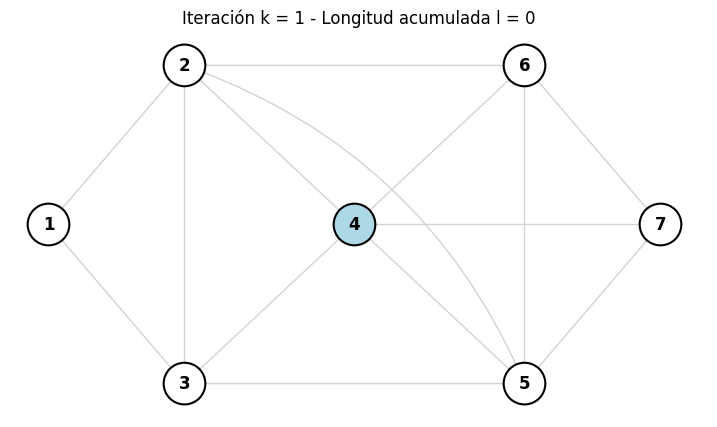

In [ ]:
dibujar(1)

### Paso 2
Se revisan las redes conectadas a los nodos de $C_1=\{4\}$ con los nodos de $\overline{C}_1$:
$$4-2=7,\quad 4-3=6,\quad 4-5=3,\quad 4-6=4,\quad 4-7=6.$$

La arista de menor distancia es $\boxed{4-5=3}$, así que $j^*=5$.

Por lo tanto $C_2=\{4,5\}$ y $\overline{C}_2=\{1,2,3,6,7\}$.
La longitud acumulada es $l=0+3=3$.

redes candidatas (C -> C barras):
4-5=3
4-6=4
4-3=6
4-7=6
4-2=7
Se elige 4-5=3 -> j*=5
C2 = [4, 5]
C barra 2 = [1, 2, 3, 6, 7]
l = 0 + 3 = 3


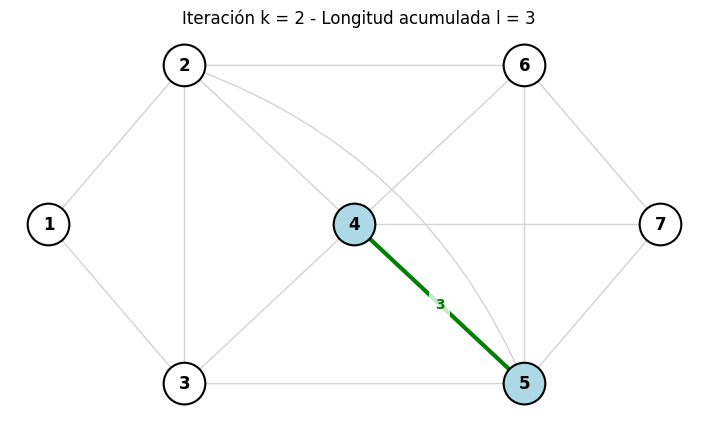

In [ ]:
iteracion(2)
dibujar(2)

### Paso 3
Se revisan las redes conectadas a los nodos de $C_2=\{4,5\}$ con los nodos de $\overline{C}_2=\{1,2,3,6,7\}$:
$$4-2=7,\quad 4-3=6,\quad 4-6=4,\quad 4-7=6,$$
$$5-2=1,\quad 5-3=7,\quad 5-6=5,\quad 5-7=9.$$
La red de menor distancia es $\boxed{5-2=1}$, así que $j^*=2$.

Por lo tanto $C_3=\{2,4,5\}$ y $\overline{C}_3=\{1,3,6,7\}$.
La longitud acumulada es $l=3+1=4$.

redes candidatas (C -> C barras):
5-2=1
4-6=4
5-6=5
4-3=6
4-7=6
4-2=7
5-3=7
5-7=9
Se elige 5-2=1 -> j*=2
C3 = [2, 4, 5]
C barra 3 = [1, 3, 6, 7]
l = 3 + 1 = 4


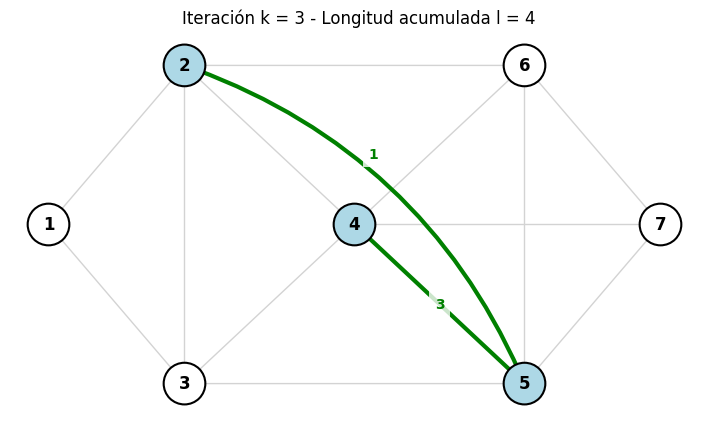

In [ ]:
iteracion(3)
dibujar(3)

### Paso 4
Ahora $C_3=\{2,4,5\}$ y $\overline{C}_3=\{1,3,6,7\}$. Las distnacias son:
$$2-1=5,\quad 2-3=2,\quad 2-6=6,\quad 4-3=6,\quad 4-6=4,$$
$$4-7=6,\quad 5-3=7,\quad 5-6=5,\quad 5-7=9.$$
La red de menor distancia es $\boxed{2-3=2}$, así que $j^*=3$.

Por lo tanto $C_4=\{2,3,4,5\}$ y $\overline{C}_4=\{1,6,7\}$.
La longitud acumulada es $l=4+2=6$.

redes candidatas (C -> C barras):
2-3=2
4-6=4
2-1=5
5-6=5
2-6=6
4-3=6
4-7=6
5-3=7
5-7=9
Se elige 2-3=2 -> j*=3
C4 = [2, 3, 4, 5]
C barra 4 = [1, 6, 7]
l = 4 + 2 = 6


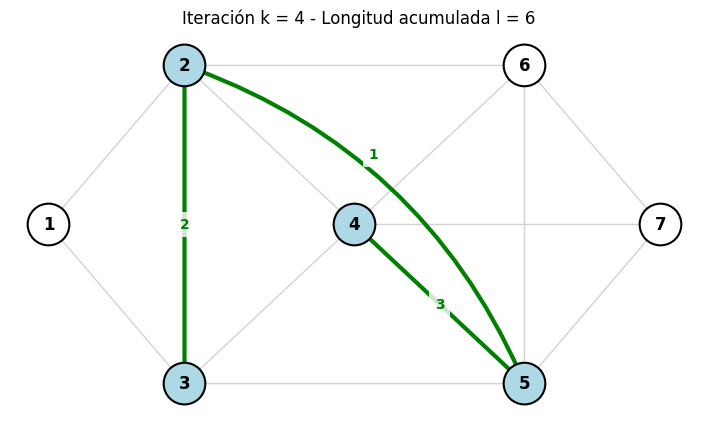

In [ ]:
iteracion(4)
dibujar(4)

### Paso 5
Con $C_4=\{2,3,4,5\}$ y $\overline{C}_4=\{1,6,7\}$, las distancias son:
$$2-1=5,\quad 2-6=6,\quad 3-1=1,\quad 4-6=4,\quad 4-7=6,\quad 5-6=5,\quad 5-7=9.$$
La red de menor distancia es $\boxed{3-1=1}$, así que $j^*=1$.

Por lo tanto $C_5=\{1,2,3,4,5\}$ y $\overline{C}_5=\{6,7\}$.
La longitud acumulada es $l=6+1=7$.

redes candidatas (C -> C barras):
3-1=1
4-6=4
2-1=5
5-6=5
2-6=6
4-7=6
5-7=9
Se elige 3-1=1 -> j*=1
C5 = [1, 2, 3, 4, 5]
C barra 5 = [6, 7]
l = 6 + 1 = 7


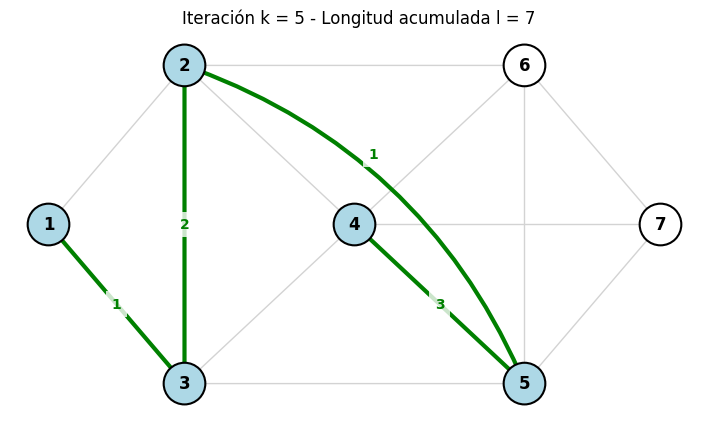

In [ ]:
iteracion(5)
dibujar(5)

### Paso 6
Con $C_5=\{1,2,3,4,5\}$ y $\overline{C}_5=\{6,7\}$, las distancias son:
$$2-6=6,\quad 4-6=4,\quad 5-6=5,\quad 4-7=6,\quad 5-7=9.$$
La red de menor distancia es $\boxed{4-6=4}$, así que $j^*=6$.

Por lo tanto $C_6=\{1,2,3,4,5,6\}$ y $\overline{C}_6=\{7\}$.
La longitud acumulada es $l=7+4=11$.

redes candidatas (C -> C barras):
4-6=4
5-6=5
2-6=6
4-7=6
5-7=9
Se elige 4-6=4 -> j*=6
C6 = [1, 2, 3, 4, 5, 6]
C barra 6 = [7]
l = 7 + 4 = 11


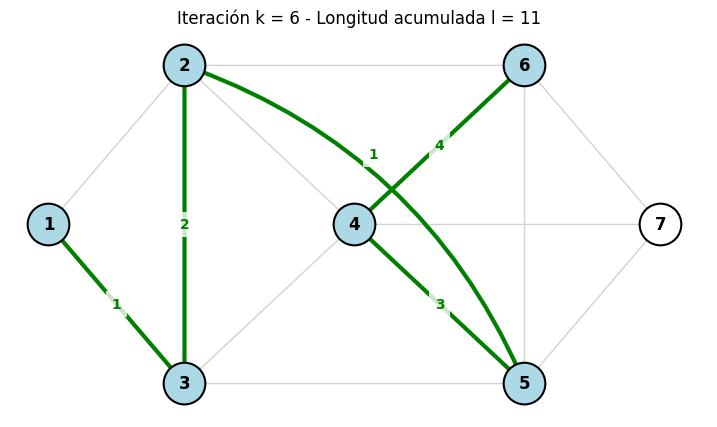

In [ ]:
iteracion(6)
dibujar(6)

### Paso 7
Con $C_6=\{1,2,3,4,5,6\}$ y $\overline{C}_6=\{7\}$, las distancias son:
$$4-7=6,\quad 5-7=9,\quad 6-7=2.$$
La red de menor distancia es $\boxed{6-7=2}$, así que $j^*=7$.

Por lo tanto $C_7=N$ y $\overline{C}_7=\emptyset$.
La longitud acumulada final es $l=11+2=13$.

Como el conjunto de nodos no conectados quedó vacío, el algoritmo se detiene.

redes candidatas (C -> C barras):
6-7=2
4-7=6
5-7=9
Se elige 6-7=2 -> j*=7
C7 = [1, 2, 3, 4, 5, 6, 7]
C barra 7 = []
l = 11 + 2 = 13


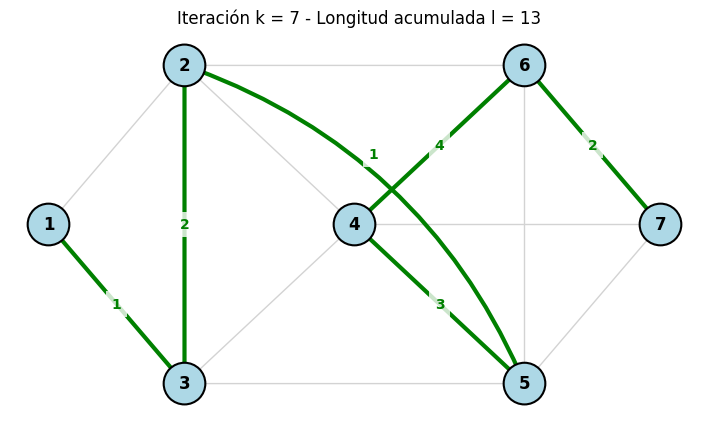

In [ ]:
iteracion(7)
dibujar(7)

### Resultado final
Las redes que forman el árbol de expansión mínima son
$(4,5),\ (5,2),\ (2,3),\ (3,1),\ (4,6),\ (6,7)$.

Así, al haber ejecutado cada iteraciòn en base al algoritmo  obtuvimos:

$$l_{\min}=3+1+2+1+4+2$$
y finalmente
$$\boxed{l_{\min}=13}.$$

### Comprobación con NetworkX
Realizaremos una comprobaciòn con la función `nx.minimum_spanning_tree` que calcula el árbol de expansión mínima directamente.

In [ ]:
T = nx.minimum_spanning_tree(U, algorithm="prim", weight="weight")
print("Aristas de NetworkX:", sorted(T.edges(data="weight")))
print("Longitud total:", T.size(weight="weight"))
print("Aristas de mi algoritmo:", estado[7]["arbol"])
print("Longitud de mi algoritmo:", estado[7]["l"])

Aristas de NetworkX: [(1, 3, 1), (2, 3, 2), (2, 5, 1), (4, 5, 3), (6, 4, 4), (6, 7, 2)]
Longitud total: 13.0
Aristas de mi algoritmo: [(4, 5, 3), (5, 2, 1), (2, 3, 2), (3, 1, 1), (4, 6, 4), (6, 7, 2)]
Longitud de mi algoritmo: 13


$2)$ Resolviendo por la ruta más corta

In [ ]:
from IPython.display import Image, display

url = "https://raw.githubusercontent.com/CruzJulio05/Investigaci-n-de-operaciones-/main/actividad_1_a.png"
display(Image(url=url))

In [ ]:
import pandas as pd

aristas = [
    (1,2,5),(1,3,1),(3,2,2),(2,6,6),(6,2,7),(2,4,7),(2,5,1),
    (3,4,6),(4,3,7),(3,5,7),(4,6,4),(4,7,6),(5,4,3),(5,6,5),
    (5,7,9),(6,7,2)
]

G = nx.DiGraph()
G.add_weighted_edges_from(aristas)
print("Nodos:", G.number_of_nodes(), "Arcos:", G.number_of_edges())

Nodos: 7 Arcos: 16


In [ ]:
pos = {1:(0.0,1.0), 2:(1.6,2.0), 3:(1.6,0.0), 4:(3.6,1.0),
       6:(5.6,2.0), 5:(5.6,0.0), 7:(7.2,1.0)}
curvas = {(2,6):0.25, (6,2):0.25, (3,4):0.25, (4,3):0.25, (2,5):-0.2}

est = {0: {"dist": {1: 0}, "pred": {1: []}, "filas": []}}

def iteracion_tabla(k):
    previo = est[k - 1]
    dist = dict(previo["dist"])
    pred = {n: list(p) for n, p in previo["pred"].items()}

    cand = []
    for r in previo["dist"]:
        libres = {j: G[r][j]["weight"] for j in G.successors(r) if j not in dist}
        if libres:
            dmin = min(libres.values())
            cand += [(r, j, d) for j, d in libres.items() if d == dmin]

    totales = [(r, j, dist[r] + d) for r, j, d in cand]
    minimo = min(t for r, j, t in totales)
    ganadores = [(r, j) for r, j, t in totales if t == minimo]
    nuevos = sorted({j for r, j in ganadores})

    for r, j in ganadores:
        dist[j] = minimo
        pred.setdefault(j, []).append(r)

    n_ini = len(previo["dist"])
    n_txt = ", ".join(str(n_ini + i) for i in range(len(nuevos)))
    filas = []
    for idx, (r, j, t) in enumerate(totales):
        d = t - previo["dist"][r]
        gana = (r, j) in ganadores
        filas.append({
            "n": n_txt if idx == 0 else "",
            "Nodo resuelto conectado": r,
            "Nodo no resuelto más cercano": j,
            "Distancia total": f"{d}" if previo["dist"][r] == 0 else f"{previo['dist'][r]} + {d} = {t}",
            "n-ésimo nodo más cercano": j if gana else "",
            "Distancia mínima": minimo if gana else "",
            "Última conexión": f"{r} → {j}" if gana else "",
        })
    est[k] = {"dist": dist, "pred": pred, "filas": filas}
    print(f"Iteración {k}: se resuelve el nodo {nuevos} con distancia {minimo}")

In [ ]:
def arco(ax, u, v, **estilo):
    r = curvas.get((u, v), 0)
    nx.draw_networkx_edges(G, pos, ax=ax, edgelist=[(u, v)], node_size=900,
                           arrows=True, arrowstyle="-|>", arrowsize=15,
                           connectionstyle=f"arc3,rad={r}", **estilo)
    (x1, y1), (x2, y2) = pos[u], pos[v]
    xm = (x1 + x2) / 2 + r * (y2 - y1) / 2
    ym = (y1 + y2) / 2 - r * (x2 - x1) / 2
    ax.text(xm, ym, str(G[u][v]["weight"]), fontsize=9, ha="center", va="center",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.8))

def dibujar_tabla(k, ruta=None):
    e = est[k]
    fig, ax = plt.subplots(figsize=(9, 5))
    ultimas = {(p, n) for n, ps in e["pred"].items() for p in ps}
    en_ruta = set(zip(ruta, ruta[1:])) if ruta else set()
    for u, v in G.edges:
        if (u, v) in en_ruta:
            arco(ax, u, v, edge_color="green", width=3)
        elif (u, v) in ultimas and not ruta:
            arco(ax, u, v, edge_color="green", width=2)
        else:
            arco(ax, u, v, edge_color="lightgray", width=1)
    colores = ["lightgreen" if n in e["dist"] else "white" for n in G.nodes]
    nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colores, node_size=900,
                           edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(G, pos, ax=ax, font_weight="bold")
    for n, d in e["dist"].items():
        x, y = pos[n]
        ax.text(x, y + 0.28, f"{d}", ha="center", fontsize=10,
                color="darkred", fontweight="bold")
    ax.set_title(f"Iteración {k}")
    ax.margins(0.15)
    ax.axis("off")
    plt.show()

Iteración 1: se resuelve el nodo [3] con distancia 1


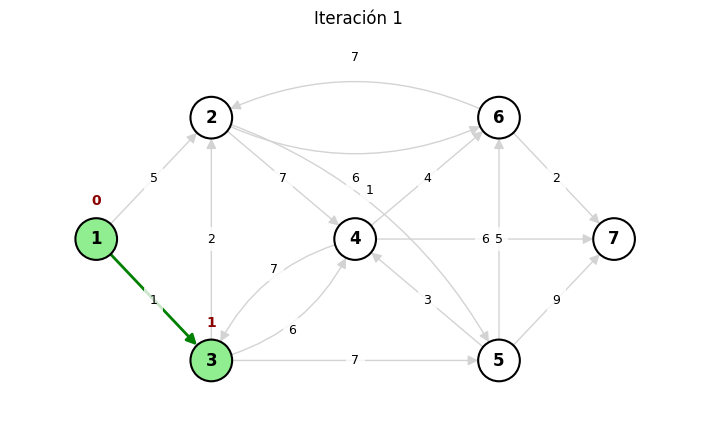

In [ ]:
iteracion_tabla(1)
dibujar_tabla(1)

In [ ]:
for k in range(1, 7):
    iteracion_tabla(k)

Iteración 1: se resuelve el nodo [3] con distancia 1
Iteración 2: se resuelve el nodo [2] con distancia 3
Iteración 3: se resuelve el nodo [5] con distancia 4
Iteración 4: se resuelve el nodo [4] con distancia 7
Iteración 5: se resuelve el nodo [6] con distancia 9
Iteración 6: se resuelve el nodo [7] con distancia 11


In [ ]:
filas = [f for k in range(1, 7) for f in est[k]["filas"]]
tabla = pd.DataFrame(filas)
display(tabla.style.hide(axis="index"))

n,Nodo resuelto conectado,Nodo no resuelto más cercano,Distancia total,n-ésimo nodo más cercano,Distancia mínima,Última conexión
1,1,3,1,3,1,1 → 3
2,1,2,5,,,
,3,2,1 + 2 = 3,2,3,3 → 2
3,3,4,1 + 6 = 7,,,
,2,5,3 + 1 = 4,5,4,2 → 5
4,3,4,1 + 6 = 7,4,7,3 → 4
,2,6,3 + 6 = 9,,,
,5,4,4 + 3 = 7,4,7,5 → 4
5,2,6,3 + 6 = 9,6,9,2 → 6
,5,6,4 + 5 = 9,6,9,5 → 6


1 → 3 → 2 → 6 → 7 | d = 11
1 → 3 → 2 → 5 → 6 → 7 | d = 11


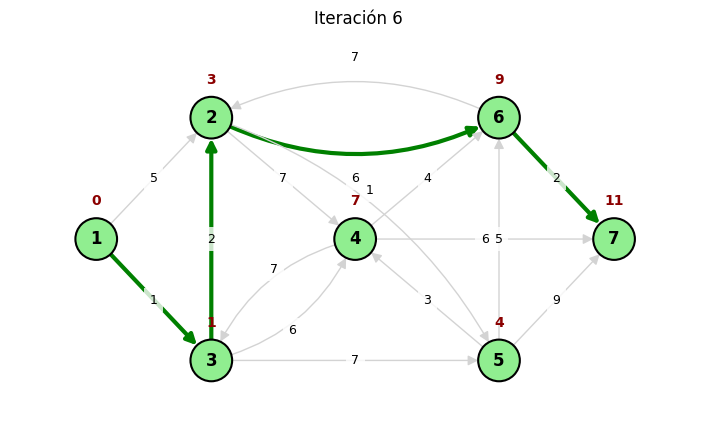

In [ ]:
pred = est[6]["pred"]

def rutas(nodo):
    if nodo == 1:
        return [[1]]
    return [r + [nodo] for p in pred[nodo] for r in rutas(p)]

for r in rutas(7):
    print(" → ".join(map(str, r)), "| d =", est[6]["dist"][7])
dibujar_tabla(6, ruta=rutas(7)[0])

### Ruta óptima
Leyendo la tabla de abajo hacia arriba: $7 \leftarrow 6 \leftarrow 2 \leftarrow 3 \leftarrow 1$ y, por el empate en el nodo 6, también $7 \leftarrow 6 \leftarrow 5 \leftarrow 2 \leftarrow 3 \leftarrow 1$.

$$\boxed{d_{\min}=11}\qquad 1\to3\to2\to6\to7 \ \ \text{o}\ \ 1\to3\to2\to5\to6\to7$$

In [ ]:
d = nx.shortest_path_length(G, source=1, target=7, weight="weight", method="dijkstra")
print(d, list(nx.all_shortest_paths(G, 1, 7, weight="weight")))

11 [[1, 3, 2, 6, 7], [1, 3, 2, 5, 6, 7]]


$3)$ Resolviendo el probema de flujo máximo

Para resolver el problema se utiliza el **algoritmo de trayectorias de aumento**.

Se tiene una red dirigida con origen en el nodo $1$ y destino en el nodo $5$. La **red residual** muestra las capacidades restantes $(c_{ij},c_{ji})$ para asignar flujos adicionales. Una **trayectoria de aumento** es una trayectoria dirigida del origen al destino cuyos arcos tienen capacidad residual estrictamente positiva.

En cada iteración se selecciona una trayectoria y se determina su capacidad residual:
$$c^*=\min\{c_{ij}\ :\ (i,j)\in\text{trayectoria}\}$$

Después se actualiza la red residual:

- Se resta $c^*$ a los arcos de la trayectoria, en el sentido de la trayectoria.
- Se suma $c^*$ a los arcos en el sentido contrario.

El procedimiento termina cuando ya no existe una trayectoria de aumento del origen al destino. El flujo máximo es la suma de las $c^*$ de todas las trayectorias y, por el teorema del flujo máximo y corte mínimo, es igual al valor del corte mínimo.

In [ ]:
import networkx as nx
from IPython.display import Image, display
url_b = "https://raw.githubusercontent.com/CruzJulio05/Investigaci-n-de-operaciones-/main/actividad_1_b.png"
display(Image(url=url_b))
arcos = [
    (1, 2, 8, 0), (1, 3, 14, 0), (1, 5, 4, 0),
    (2, 3, 5, 10), (2, 4, 7, 6), (2, 5, 6, 0),
    (3, 4, 9, 7), (3, 5, 10, 0),
    (4, 5, 5, 0),
]

H = nx.DiGraph()
for i, j, cij, cji in arcos:
    H.add_edge(i, j, capacity=cij)
    H.add_edge(j, i, capacity=cji)

res0 = {}
for i, j, cij, cji in arcos:
    res0[(i, j)] = cij
    res0[(j, i)] = cji

nodos = [1, 2, 3, 4, 5]
fuente, sumidero = 1, 5
est_f = {0: {"res": res0, "F": 0, "ruta": None, "fp": None}}

In [ ]:
def iteracion_flujo(p):
    res = dict(est_f[p - 1]["res"])
    etiquetas = {fuente: (float("inf"), None)}
    tachados = set()
    i = fuente
    print(f"Iteración {p}")
    while True:
        S = [j for j in nodos
             if j not in etiquetas and j not in tachados and res.get((i, j), 0) > 0]
        print(f"  i = {i}: S{i} = {S}")
        if S:
            k = max(S, key=lambda j: (res[(i, j)], -j))
            etiquetas[k] = (res[(i, k)], i)
            print(f"  k = {k}: etiqueta [{res[(i, k)]}, {i}]")
            if k == sumidero:
                break
            i = k
        else:
            if i == fuente:
                print("  No hay más rutas de irrupción")
                est_f[p] = {"res": res, "F": est_f[p - 1]["F"], "ruta": None, "fp": 0}
                return
            r = etiquetas[i][1]
            tachados.add(i)
            print(f"  Retroceso: se tacha el nodo {i} y se regresa a {r}")
            i = r
    ruta = [sumidero]
    while ruta[-1] != fuente:
        ruta.append(etiquetas[ruta[-1]][1])
    ruta.reverse()
    fp = min(etiquetas[n][0] for n in ruta)
    for a, b in zip(ruta, ruta[1:]):
        res[(a, b)] -= fp
        res[(b, a)] += fp
    est_f[p] = {"res": res, "F": est_f[p - 1]["F"] + fp, "ruta": ruta, "fp": fp}
    print(f"  Ruta {ruta}, f{p} = {fp}, F acumulado = {est_f[p]['F']}")

In [ ]:
posf = {1: (0.0, 1.0), 3: (2.5, 2.6), 5: (5.0, 1.0), 2: (1.0, 0.0), 4: (4.0, 0.0)}

def dibujar_flujo(p):
    e = est_f[p]
    fig, ax = plt.subplots(figsize=(9, 5.5))
    en_ruta = set(zip(e["ruta"], e["ruta"][1:])) if e["ruta"] else set()
    for i, j, cij, cji in arcos:
        (x1, y1), (x2, y2) = posf[i], posf[j]
        usado = (i, j) in en_ruta or (j, i) in en_ruta
        ax.plot([x1, x2], [y1, y2], color="green" if usado else "gray",
                lw=3 if usado else 1, zorder=1)
        dx, dy = x2 - x1, y2 - y1
        largo = (dx ** 2 + dy ** 2) ** 0.5
        ux, uy = -dy / largo, dx / largo
        for a, b, t in ((i, j, 0.25), (j, i, 0.75)):
            tx = x1 + t * dx + 0.13 * ux
            ty = y1 + t * dy + 0.13 * uy
            ax.text(tx, ty, str(e["res"][(a, b)]), color="darkred", fontsize=10,
                    fontweight="bold", ha="center", va="center", zorder=3,
                    bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    nx.draw_networkx_nodes(H, posf, ax=ax, node_color="lightblue", node_size=900,
                           edgecolors="black", linewidths=1.5)
    nx.draw_networkx_labels(H, posf, ax=ax, font_weight="bold")
    titulo = f"Iteración {p}"
    if e["ruta"]:
        titulo += f": ruta {e['ruta']}, f = {e['fp']}, F = {e['F']}"
    ax.set_title(titulo)
    ax.margins(0.12)
    ax.axis("off")
    plt.show()

Iteración 1
  i = 1: S1 = [2, 3, 5]
  k = 3: etiqueta [14, 1]
  i = 3: S3 = [2, 4, 5]
  k = 2: etiqueta [10, 3]
  i = 2: S2 = [4, 5]
  k = 4: etiqueta [7, 2]
  i = 4: S4 = [5]
  k = 5: etiqueta [5, 4]
  Ruta [1, 3, 2, 4, 5], f1 = 5, F acumulado = 5


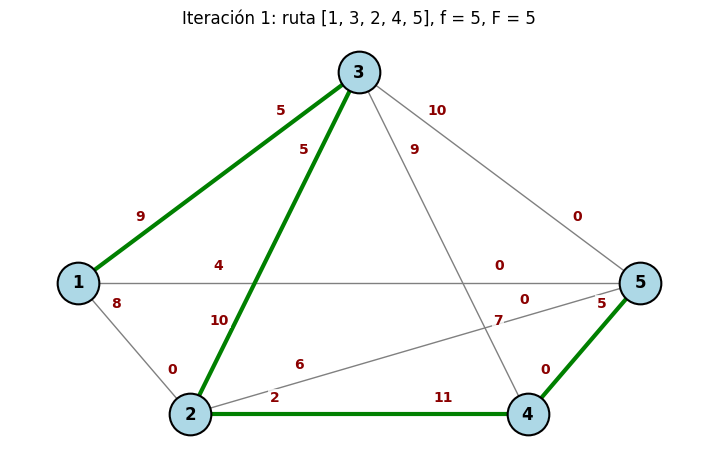

In [ ]:
iteracion_flujo(1)
dibujar_flujo(1)